In [1]:
NUM_AGENTS = 2
HEIGHT = 6
WIDTH = 6
SPAWN_PROB_PER_CELL = 0.05
DESPAWN_PROB_PER_CELL = 0.09

# Parameters
ENV_ITERATIONS = 100000
DISCOUNT = 0.99
EPSILON = 0.1
LEARNING_RATE = 0.00002
BATCH_SIZE = 1


HIDDEN_FEATURES = 128
HIDDEN_LAYERS = 4

In [2]:
import sys
sys.path.append("../..")
from models.value_cnn import ValueCNNCentralized
import numpy as np
from orchard.environment import Action2D, OrchardBasic
from tqdm import tqdm
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- PyTorch is configured to use: {DEVICE} ---")

--- PyTorch is configured to use: cuda ---
--- PyTorch is configured to use: cuda ---


In [3]:
from dataclasses import dataclass
from typing import Any

@dataclass
class Position:
    row: int
    col: int
    def np_array(self):
        return np.array([self.row, self.col])

@dataclass
class State:
    apples: np.ndarray[Any, np.dtype[np.int_]]
    agents: np.ndarray[Any, np.dtype[np.int_]]
    name: str = "State"
    def __hash__(self):
        # Convert the numpy arrays to their byte representation, which is hashable
        return hash((self.agents.tobytes(), self.apples.tobytes()))

    def __eq__(self, other):
        # Define how to check for equality between two State objects
        return np.array_equal(self.agents, other.agents) and np.array_equal(self.apples, other.apples)

In [4]:
def simulate_step(s: State, agent_idx: int, agent_positions: np.ndarray, action_vector: np.ndarray):
    """
    Simulates an agent taking an action. Does not modify in place.
    
    Returns:
        tuple: (reward: int, next_state: State, new_agent_positions: np.ndarray)
    """
    current_agents = s.agents
    current_apples = s.apples
    agent_pos = agent_positions[agent_idx]
    grid_shape = current_agents.shape
    
    new_position = np.clip(
        agent_pos + action_vector, [0, 0], np.array(grid_shape) - 1
    )
    
    next_agents = current_agents.copy()
    next_apples = current_apples.copy()
    
    next_agents[tuple(new_position)] += 1
    next_agents[tuple(agent_pos)] -= 1
    
    # The new positions array must be updated
    new_agent_positions = agent_positions.copy()
    new_agent_positions[agent_idx] = new_position
    
    reward = 0
    if next_apples[tuple(new_position)] > 0:
        next_apples[tuple(new_position)] -= 1
        reward = 1
        
    return reward, State(apples=next_apples, agents=next_agents), new_agent_positions

### Get CNN Centralized Estimate Value

In [5]:
import numpy as np
import torch
import matplotlib.pyplot as plt

history = {
    "loss": [],
    "reward_mean": [],
    "reward_std": [],
    "target_mean": [],
    "target_std": [],
    "pred_mean": [],
    "pred_std": [],
    "corr": [],
}

def log_batch_stats(net: ValueCNNCentralized):
    """Compute and store one-line summary statistics per batch."""
    with torch.no_grad():
        if len(net.batch_states) == 0:
            return
        device = next(net.parameters()).device  # automatically detect whether the net is on cpu or cuda

        states = torch.tensor(np.stack(net.batch_states), dtype=torch.float32, device=device)
        next_states = torch.tensor(np.stack(net.batch_new_states), dtype=torch.float32, device=device)
        rewards = torch.tensor(net.batch_rewards, dtype=torch.float32, device=device)
        preds = net.forward(states).squeeze(1)
        targets = rewards + net.trainer.discount * net.forward(next_states).squeeze(1)
        preds_np, targets_np, rewards_np = preds.cpu().numpy(), targets.cpu().numpy(), rewards.cpu().numpy()
        corr = np.corrcoef(preds_np, targets_np)[0, 1] if len(preds_np) > 1 else np.nan

    history["reward_mean"].append(np.mean(rewards_np))
    history["reward_std"].append(np.std(rewards_np))
    history["target_mean"].append(np.mean(targets_np))
    history["target_std"].append(np.std(targets_np))
    history["pred_mean"].append(np.mean(preds_np))
    history["pred_std"].append(np.std(preds_np))
    history["corr"].append(corr)
    
def state_to_raw_dict(s: State) -> dict:
    return {"apples": s.apples, "agents": s.agents}



In [6]:
def Q_team(s_t_plus_1: State, r_team: float, cnn: ValueCNNCentralized):
    return r_team + DISCOUNT * cnn.get_model_reward_prediction_from_raw(state_to_raw_dict(s_t_plus_1))

def train_value_cnn(cnn: ValueCNNCentralized, s_t: State, r_t: float, s_t_plus_1: State):
    raw_state_t = {"apples": s_t.apples, "agents": s_t.agents}
    raw_state_t_plus_1 = {"apples": s_t_plus_1.apples, "agents": s_t_plus_1.agents}
    processed_state_t = cnn.raw_state_to_nn_input(raw_state_t)
    processed_state_t_plus_1 = cnn.raw_state_to_nn_input(raw_state_t_plus_1)
    cnn.add_experience(processed_state_t, processed_state_t_plus_1, r_t)
    
    if len(cnn.batch_states) >= BATCH_SIZE:
        log_batch_stats(cnn)
        cnn.train_batch()

def argmax_a_of_Q_team(s_t, agent_idx: int, agent_positions: np.ndarray, value_CNN_centralized: ValueCNNCentralized):
    max_q = -float('inf')
    best_action = Action2D.STAY
    for action in Action2D:
        r_t, s_t_plus_1, new_agent_positions = simulate_step(s_t, agent_idx, agent_positions, action.vector)
        q_value = Q_team(s_t_plus_1, r_t, value_CNN_centralized)
        if q_value > max_q:
            max_q = q_value
            best_action = action
    return best_action

In [7]:
def spawn_apples(s: State):
    p_cell = SPAWN_PROB_PER_CELL
    H, L = s.apples.shape  # ★ rows = width, cols = length

    rand_mat = np.random.rand(H, L)  # ★ new RNG draw, same shape
    spawn_mask = rand_mat < p_cell
    spawn_mask = spawn_mask & (
        s.agents == 0
    )  # KEY CHANGE: only spawn where there are no agents.
    s.apples[spawn_mask] += 1
    return s

def despawn_apples(s: State):
    """
    One 'second-boundary' update:
      • despawn apples with geom-hazard q = 1/T
      • spawn new apples in empty cells with p_cell = r · s_target
    Call exactly once after every n micro-ticks.
    """
    q_despawn = DESPAWN_PROB_PER_CELL
    H, L = s.apples.shape  # ★ rows = width, cols = length

    # ---- despawn ----
    rand_mat = np.random.rand(H, L)  # ★ same shape as s.apples
    mask_apples = s.apples != 0
    removal_mask = mask_apples & (rand_mat < q_despawn)
    s.apples[removal_mask] -= 1
    return removal_mask.sum()

def init_empty_state():
    return State(
        apples=np.zeros((HEIGHT, WIDTH), dtype=int),
        agents=np.zeros((HEIGHT, WIDTH), dtype=int),
    )

def place_agents_randomly(s: State, num_agents: int):
    H, L = s.agents.shape
    empty_positions = np.argwhere(s.agents == 0)
    chosen_indices = np.random.choice(len(empty_positions), size=num_agents, replace=False)
    for index in chosen_indices:
        pos = empty_positions[index]
        s.agents[tuple(pos)] = 1
    return s

In [8]:
value_CNN_centralized = ValueCNNCentralized(HEIGHT, WIDTH, LEARNING_RATE, DISCOUNT, HIDDEN_FEATURES, HIDDEN_LAYERS)
s_0 = init_empty_state()
place_agents_randomly(s_0, NUM_AGENTS)
agent_positions = np.argwhere(s_0.agents == 1)

print(f"s_0: {s_0}")
print(f"agent_positions: {agent_positions}")

s_0: State(apples=array([[0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0]]), agents=array([[0, 1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0]]), name='State')
agent_positions: [[0 1]
 [1 1]]


In [14]:
# 4 sample states. s_0, early_state, mid_state, high_value_state
early_state = None
s_t = s_0
for t in range(50):
    c = np.random.randint(0, len(agent_positions))
    p = np.random.random()
    action = Action2D.get_random_action()
        
    r_t, s_t_plus_1, agent_positions = simulate_step(s_t, c, agent_positions, action.vector)
    
    s_t = s_t_plus_1
    spawn_apples(s_t)
    despawn_apples(s_t)
    if t == 10:
        early_state = s_t
        early_state.name = "early_state"
mid_state = s_t
mid_state.name = "mid_state"
high_value_state = State(
    apples=np.array(
        [
            [5, 5, 0, 0, 0, 0],
            [5, 5, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 5, 5],
            [0, 0, 0, 0, 5, 5],
        ]
    ),
    agents=np.array(
        [
            [0, 0, 0, 0, 0, 0],
            [0, 1, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 1, 0],
            [0, 0, 0, 0, 0, 0],
        ]),
    name = "high_value_state"
)
print(f"early_state: {early_state}")
print(f"mid_state: {mid_state}")
print(f"high_value_state: {high_value_state}")
sample_states = [s_0, early_state, mid_state, high_value_state]

early_state: State(apples=array([[0, 0, 0, 1, 0, 1],
       [0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 2],
       [1, 1, 1, 0, 0, 0],
       [0, 1, 0, 1, 0, 1]]), agents=array([[-1,  1,  1,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0],
       [ 0,  0,  1,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0]]), name='early_state')
mid_state: State(apples=array([[0, 0, 0, 0, 0, 0],
       [3, 2, 2, 0, 0, 1],
       [0, 0, 0, 0, 0, 2],
       [0, 0, 0, 0, 0, 0],
       [1, 1, 0, 1, 0, 0],
       [0, 0, 2, 0, 1, 0]]), agents=array([[-1,  1,  0,  0,  1,  0],
       [ 0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  1,  0,  0],
       [ 0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0]]), name='mid_state')
high_value_state: State(apples=array([[5, 5, 0, 0, 0, 0],
       [5, 5, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 5, 5],
    

In [ ]:
NUM_TO_AVERAGE_OVER = 10
# use monte carlo to calculate true state values
for state in sample_states:
    total_values = []
    for n in tqdm(range(NUM_TO_AVERAGE_OVER), desc=f"Estimating true value for state: {state.name}"):
        s_t = state
        total_value = 0
        discount_factor = 1.0
        for t in range(1000):
            c = np.random.randint(0, len(agent_positions))
            action = Action2D.get_random_action()
            
            r_t, s_t_plus_1, agent_positions = simulate_step(s_t, c, agent_positions, action.vector)
            
            total_value += discount_factor * r_t
            discount_factor *= DISCOUNT
            
            s_t = s_t_plus_1
            spawn_apples(s_t)
            despawn_apples(s_t)
        total_values.append(total_value)
    avg_value = np.mean(total_values)
    print(f"Estimated true value of state:\n{state.name}\n is approximately: {avg_value}\n")

Estimated true value of state:
State
 is approximately: 10.055971855823291

Estimated true value of state:
early_state
 is approximately: 12.496729325288923

Estimated true value of state:
mid_state
 is approximately: 13.171914377806303

Estimated true value of state:
high_value_state
 is approximately: 14.867224037126467



In [ ]:
s_t = s_0
for t in tqdm(range(ENV_ITERATIONS), desc="Env steps"):
    c = np.random.randint(0, len(agent_positions))
    p = np.random.random()
    action = Action2D.get_random_action()
        
    r_t, s_t_plus_1, agent_positions = simulate_step(s_t, c, agent_positions, action.vector)
    train_value_cnn(value_CNN_centralized, s_t, r_t, s_t_plus_1)
    
    s_t = s_t_plus_1
    spawn_apples(s_t)
    despawn_apples(s_t)
    

Env steps:  10%|█         | 10312/100000 [01:03<09:12, 162.43it/s]


KeyboardInterrupt: 

In [ ]:
for state in sample_states:
    raw_state = {"apples": state.apples, "agents": state.agents}
    predicted_value = value_CNN_centralized.get_model_reward_prediction_from_raw(raw_state)
    print(f"Predicted value of state {state.name} by trained CNN: {predicted_value.item()}")

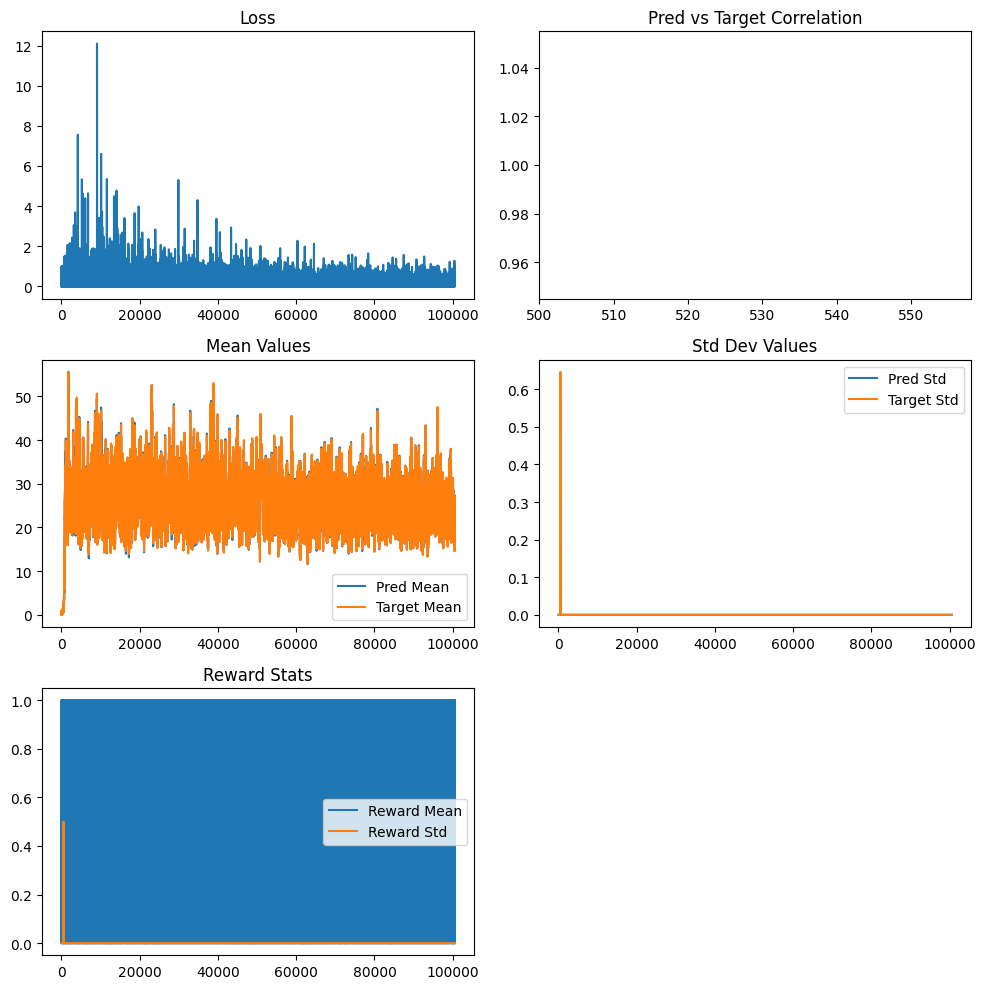

In [ ]:
def plot_training_diagnostics(value_CNN_centralized):
    fig, axs = plt.subplots(3, 2, figsize=(10, 10))
    axs = axs.flatten()

    axs[0].plot(value_CNN_centralized.loss_history)
    axs[0].set_title("Loss")

    axs[1].plot(history["corr"])
    axs[1].set_title("Pred vs Target Correlation")

    axs[2].plot(history["pred_mean"], label="Pred Mean")
    axs[2].plot(history["target_mean"], label="Target Mean")
    axs[2].set_title("Mean Values")
    axs[2].legend()

    axs[3].plot(history["pred_std"], label="Pred Std")
    axs[3].plot(history["target_std"], label="Target Std")
    axs[3].set_title("Std Dev Values")
    axs[3].legend()

    axs[4].plot(history["reward_mean"], label="Reward Mean")
    axs[4].plot(history["reward_std"], label="Reward Std")
    axs[4].set_title("Reward Stats")
    axs[4].legend()

    axs[5].axis("off")
    plt.tight_layout()
    plt.show()

plot_training_diagnostics(value_CNN_centralized)


# Run simulation to see performance

In [ ]:
def random_policy(s: State, agent_idx: int, agent_positions: np.ndarray):
    return Action2D.get_random_action()

def nearest_policy(s: State, agent_idx: int, agent_positions: np.ndarray):
    agent_pos = agent_positions[agent_idx]
    apple_positions = np.argwhere(s.apples > 0)
    if len(apple_positions) == 0:
        return Action2D.get_random_action()
    distances = np.linalg.norm(apple_positions - agent_pos, axis=1)
    nearest_apple_idx = np.argmin(distances)
    nearest_apple_pos = apple_positions[nearest_apple_idx]
    direction = nearest_apple_pos - agent_pos
    if abs(direction[0]) > abs(direction[1]):
        return Action2D.DOWN if direction[0] > 0 else Action2D.UP
    else:
        return Action2D.RIGHT if direction[1] > 0 else Action2D.LEFT

def optimal_learned_policy(s: State, agent_idx: int, agent_positions: np.ndarray):
    return argmax_a_of_Q_team(s, agent_idx, agent_positions, value_CNN_centralized)

In [ ]:
def evaluate_policy(policy_func, num_episodes: int = 1000):
    total_rewards = []
    s = init_empty_state()
    place_agents_randomly(s, NUM_AGENTS)
    agent_positions = np.argwhere(s.agents == 1)
    episode_reward = 0
    for t in range(100):  # fixed episode length
        for agent_idx in range(NUM_AGENTS):
            action = policy_func(s, agent_idx, agent_positions)
            r_t, s, agent_positions = simulate_step(s, agent_idx, agent_positions, action.vector)
            episode_reward += r_t
        spawn_apples(s)
        despawn_apples(s)
    total_rewards.append(episode_reward)
    return total_rewards

In [ ]:
optimal_rewards = evaluate_policy(optimal_learned_policy)
random_rewards = evaluate_policy(random_policy)
nearest_rewards = evaluate_policy(nearest_policy)

In [ ]:
print(f"Optimal learned policy average reward: {np.mean(optimal_rewards)}")
print(f"Random policy average reward: {np.mean(random_rewards)}")
print(f"Nearest policy average reward: {np.mean(nearest_rewards)}")

Optimal learned policy average reward: 52.0
Random policy average reward: 48.0
Nearest policy average reward: 98.0
